# Actividad - Proyecto práctico

*   Alumno 1: Yeray Quiles Ferrández
*   Alumno 2: Rodrigo Hernan Peralta
*   Alumno 3:
*   Alumno 4:
*   Alumno 5:





---
## **PARTE 1** - Instalación y requisitos previos


---
### 1.1. Preparar enviroment (local)




### Comprobaciones previas, solo usar 1 de las opciones dependiendo de la placa de video y librerias instaladas

#### NVIDIA GPU, GYM y Tensorflow

In [ ]:
# Verificación de versiones y compatibilidad de librerías para NVIDIA GPU con gym y TensorFlow
import numpy as np
import tensorflow as tf
import gym

print(f"✅ Numpy Version: {np.__version__}")       # Debe ser 1.23.5
print(f"✅ TensorFlow Version: {tf.__version__}")  # Debe ser 2.12.1
print(f"✅ Gym Version: {gym.__version__}")        # Debe ser 0.17.3

try:
    # Prueba rápida de compatibilidad
    np.bool = bool  # El parche
    env = gym.make('SpaceInvaders-v0')
    env.reset()
except Exception as e:
    print(f"❌ Algo falló: {e}")

In [ ]:
# Asingar GPU con TensorFlow para NVIDIA GPU
import tensorflow as tf
print("Buscando GPUs...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU Detectada: {gpus}")
    print("Detalles:", tf.sysconfig.get_build_info()["cuda_version"])
else:
    print("❌ Aún no se detecta la GPU.")

---
### 1.2. Importar librerías necesarias

#### gym y tensorflow

In [ ]:
# Configuración inicial del proyecto con Gym, TensorFlow y Keras-RL

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob
import time

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Convolution2D, Permute
from tensorflow.keras.optimizers.legacy import Adam 
import tensorflow.keras.backend as K

import gym
from rl.agents.dqn import DQNAgent
from rl.policy import LinearAnnealedPolicy, EpsGreedyQPolicy
from rl.memory import SequentialMemory
from rl.core import Processor
from rl.callbacks import FileLogger, ModelIntervalCheckpoint

# --- CONFIGURACIÓN DE GPU ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU Detectada y Configurada: {gpus[0].name}")
    except RuntimeError as e:
        print(f"⚠️ Error GPU: {e}")
else:
    print("❌ GPU no detectada (Se usará CPU)")

# --- CONFIGURACIÓN DE RUTAS ---
BASE_PATH = os.getcwd()
CHECKPOINT_DIR = os.path.join(BASE_PATH, "checkpoints")
LOGS_DIR = os.path.join(BASE_PATH, "logs")

for d in [CHECKPOINT_DIR, LOGS_DIR]:
    os.makedirs(d, exist_ok=True)

# --- PARCHES DE COMPATIBILIDAD ---
np.bool = bool 
ENV_NAME = 'SpaceInvaders-v0'
SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"📂 Directorio de trabajo: {BASE_PATH}")

✅ GPU Detectada y Configurada: /physical_device:GPU:0
📂 Directorio de trabajo: /home/yerayquiles16/REPOSITORIOS/08MIAR_RL


---
## **PARTE 2**. Enunciado

Consideraciones a tener en cuenta:

- El entorno sobre el que trabajaremos será _SpaceInvaders-v0_ y el algoritmo que usaremos será _DQN_.

- Para nuestro ejercicio, el requisito mínimo será alcanzado cuando el agente consiga una **media de recompensa por encima de 20 puntos en modo test**. Por ello, esta media de la recompensa se calculará a partir del código de test en la última celda del notebook.

Este proyecto práctico consta de tres partes:

1.   Implementar la red neuronal que se usará en la solución
2.   Implementar las distintas piezas de la solución DQN
3.   Justificar la respuesta en relación a los resultados obtenidos

**Rúbrica**: Se valorará la originalidad en la solución aportada, así como la capacidad de discutir los resultados de forma detallada. El requisito mínimo servirá para aprobar la actividad, bajo premisa de que la discusión del resultado sera apropiada.

IMPORTANTE:

* Si no se consigue una puntuación óptima, responder sobre la mejor puntuación obtenida.
* Para entrenamientos largos, recordad que podéis usar checkpoints de vuestros modelos para retomar los entrenamientos. En este caso, recordad cambiar los parámetros adecuadamente (sobre todo los relacionados con el proceso de exploración).
* Se deberá entregar unicamente el notebook y los pesos del mejor modelo en un fichero .zip, de forma organizada.
* Cada alumno deberá de subir la solución de forma individual.

---
## **PARTE 3**. Desarrollo y preguntas

### Modelo 1

In [12]:
# Diccionario de Hiperparámetros
HP = {
    'lr': 0.00025,           # Tasa de aprendizaje
    'memory_size': 500000,   # Memoria de repetición
    'steps': 1000000,        # Pasos para reducir la exploración (epsilon)
    'warmup': 50000,         # Pasos iniciales para llenar memoria antes de entrenar
    'update': 10000,         # Cada cuánto se actualiza la red objetivo
    'checkpoint_freq': 10000,# Guardar pesos cada X pasos
    'total_steps': 2000000,  # Duración total del entrenamiento
    'log_interval': 1000,    # Imprimir logs cada X pasos
    'gamma': 0.99,           # Factor de descuento
    'dueling': True,         # Usar arquitectura Dueling
    'dueling_type': 'avg',
    'double_dqn': True       # Usar Double DQN
}

print("⚙️ Hiperparámetros cargados.")

⚙️ Hiperparámetros cargados.


#### Configuración base

In [13]:
env = gym.make(ENV_NAME)
env.seed(SEED)
NB_ACTIONS = env.action_space.n
INPUT_SHAPE = (84, 84)
WINDOW_LENGTH = 4

In [14]:
class AtariProcessor(Processor):
    def process_observation(self, observation):
        assert observation.ndim == 3  # (height, width, channel)
        # Usamos Pillow para redimensionar (más rápido y compatible)
        img = Image.fromarray(observation)
        img = img.resize(INPUT_SHAPE).convert('L') # Escala de grises
        processed_observation = np.array(img)
        assert processed_observation.shape == INPUT_SHAPE
        return processed_observation.astype('uint8')

    def process_state_batch(self, batch):
        # Normalizar pixeles de 0-255 a 0-1
        return batch.astype('float32') / 255.

    def process_reward(self, reward):
        # Recortar recompensa entre -1 y 1 para estabilidad
        return np.clip(reward, -1., 1.)

print(f"🎮 Entorno {ENV_NAME} listo. Acciones posibles: {NB_ACTIONS}")

🎮 Entorno SpaceInvaders-v0 listo. Acciones posibles: 6


1. Implementación de la red neuronal

In [15]:
model_name = 'Modelo_D3QN'
full_input_shape = (WINDOW_LENGTH,) + INPUT_SHAPE

model = Sequential()

# Permutar dimensiones según el formato de datos de Keras (Channels Last vs First)
if K.image_data_format() == 'channels_last':
    # Entrada: (Batch, Window, Height, Width) -> Salida: (Batch, Height, Width, Window)
    model.add(Permute((2, 3, 1), input_shape=full_input_shape))
elif K.image_data_format() == 'channels_first':
    model.add(Permute((1, 2, 3), input_shape=full_input_shape))

# Capas Convolucionales
model.add(Convolution2D(32, (8, 8), strides=(4, 4), activation='relu'))
model.add(Convolution2D(64, (4, 4), strides=(2, 2), activation='relu'))
model.add(Convolution2D(64, (3, 3), strides=(1, 1), activation='relu'))

# Aplanar y capas densas
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(NB_ACTIONS, activation='linear'))

print("🧠 Modelo Compilado:")
model.summary()

🧠 Modelo Compilado:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 permute_1 (Permute)         (None, 84, 84, 4)         0         
                                                                 
 conv2d_3 (Conv2D)           (None, 20, 20, 32)        8224      
                                                                 
 conv2d_4 (Conv2D)           (None, 9, 9, 64)          32832     
                                                                 
 conv2d_5 (Conv2D)           (None, 7, 7, 64)          36928     
                                                                 
 flatten_1 (Flatten)         (None, 3136)              0         
                                                                 
 dense_3 (Dense)             (None, 512)               1606144   
                                                                 
 dense_4 (Dense)             (None

2. Implementación de la solución DQN

In [16]:
# Configuración Agente
memory = SequentialMemory(limit=HP['memory_size'], window_length=WINDOW_LENGTH)
processor = AtariProcessor()

policy = LinearAnnealedPolicy(EpsGreedyQPolicy(), attr='eps',
                              value_max=1., value_min=.1, value_test=.05,
                              nb_steps=HP['steps'])

dqn = DQNAgent(model=model, nb_actions=NB_ACTIONS, policy=policy,
               memory=memory, processor=processor,
               nb_steps_warmup=HP['warmup'],
               gamma=HP['gamma'],
               target_model_update=HP['update'],
               train_interval=4,
               enable_dueling_network=HP['dueling'],
               dueling_type=HP['dueling_type'],
               enable_double_dqn=HP['double_dqn'])

dqn.compile(Adam(learning_rate=HP['lr']), metrics=['mae'])

# Archivos y Callbacks
# Nota: Cambiamos a extensión .h5 para futuros guardados (más limpio)
weights_filename = os.path.join(BASE_PATH, f'dqn_{ENV_NAME}_{model_name}_FINAL.h5')
checkpoint_filename = os.path.join(CHECKPOINT_DIR, 'dqn_' + ENV_NAME + '_weights_{step}.h5')
log_filename = os.path.join(LOGS_DIR, f'dqn_{ENV_NAME}_{model_name}_log.json')

callbacks = [ModelIntervalCheckpoint(checkpoint_filename, interval=HP['checkpoint_freq'])]
callbacks += [FileLogger(log_filename, interval=100)]

# --- LÓGICA DE AUTO-RESUME (Detecta tus archivos .index) ---
files_h5 = glob.glob(os.path.join(CHECKPOINT_DIR, '*.h5'))
files_tf = glob.glob(os.path.join(CHECKPOINT_DIR, '*.h5f.index')) # Lo que tienes ahora

if files_h5:
    latest_file = max(files_h5, key=os.path.getctime)
    print(f"🔄 Checkpoint (.h5) encontrado: {os.path.basename(latest_file)}")
    dqn.load_weights(latest_file)
elif files_tf:
    # Lógica especial para tus archivos actuales
    latest_file = max(files_tf, key=os.path.getctime)
    base_name = latest_file.replace('.index', '') # Quitamos .index para cargar
    print(f"🔄 Checkpoint (TF Format) encontrado: {os.path.basename(latest_file)}")
    print("   Recuperando progreso del paso 50.000...")
    dqn.load_weights(base_name)
else:
    print("🆕 No se encontraron checkpoints. Iniciando desde cero.")

# --- ENTRENAMIENTO ---
print(f"▶️ Entrenando por {HP['total_steps']} pasos...")
start_time = time.time()

try:
    dqn.fit(env, callbacks=callbacks, nb_steps=HP['total_steps'],
            log_interval=HP['log_interval'], visualize=False)
    
    dqn.save_weights(weights_filename, overwrite=True)
    print(f"✅ Entrenamiento finalizado en {(time.time() - start_time)/60:.1f} minutos.")
except Exception as e:
    print(f"❌ Error: {e}")
    dqn.save_weights(weights_filename, overwrite=True)

2026-01-10 10:37:55.080461: W tensorflow/c/c_api.cc:300] Operation '{name:'conv2d_5_1/kernel/Assign' id:1264 op device:{requested: '', assigned: ''} def:{{{node conv2d_5_1/kernel/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](conv2d_5_1/kernel, conv2d_5_1/kernel/Initializer/stateless_random_uniform)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-01-10 10:37:55.262156: W tensorflow/c/c_api.cc:300] Operation '{name:'total_5/Assign' id:1456 op device:{requested: '', assigned: ''} def:{{{node total_5/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](total_5, total_5/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error 

🔄 Checkpoint (TF Format) encontrado: dqn_SpaceInvaders-v0_weights_60000.h5f.index
   Recuperando progreso del paso 50.000...
▶️ Entrenando por 2000000 pasos...
Training for 2000000 steps ...
Interval 1 (0 steps performed)
  45/1000 [>.............................] - ETA: 3s - reward: 0.0000e+00

2026-01-10 10:37:55.308813: W tensorflow/c/c_api.cc:300] Operation '{name:'lambda_1_1/sub' id:1200 op device:{requested: '', assigned: ''} def:{{{node lambda_1_1/sub}} = Sub[T=DT_FLOAT, _has_manual_control_dependencies=true](lambda_1_1/add, lambda_1_1/Mean)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


1000/1000 [==============================] - 3s 3ms/step - reward: 0.0120
1 episodes - episode_reward: 6.000 [6.000, 6.000] - ale.lives: 2.137

Interval 2 (1000 steps performed)
1000/1000 [==============================] - 3s 3ms/step - reward: 0.0110
2 episodes - episode_reward: 8.500 [7.000, 10.000] - ale.lives: 2.242

Interval 3 (2000 steps performed)
1000/1000 [==============================] - 3s 3ms/step - reward: 0.0150
1 episodes - episode_reward: 12.000 [12.000, 12.000] - ale.lives: 2.122

Interval 4 (3000 steps performed)
1000/1000 [==============================] - 3s 3ms/step - reward: 0.0110
1 episodes - episode_reward: 6.000 [6.000, 6.000] - ale.lives: 2.050

Interval 5 (4000 steps performed)
1000/1000 [==============================] - 3s 3ms/step - reward: 0.0120
2 episodes - episode_reward: 10.000 [8.000, 12.000] - ale.lives: 2.082

Interval 6 (5000 steps performed)
1000/1000 [==============================] - 2s 2ms/step - reward: 0.0080
1 episodes - episode_reward: 3

2026-01-10 10:40:11.829293: W tensorflow/c/c_api.cc:300] Operation '{name:'lambda_1_2/sub' id:1342 op device:{requested: '', assigned: ''} def:{{{node lambda_1_2/sub}} = Sub[T=DT_FLOAT, _has_manual_control_dependencies=true](lambda_1_2/add, lambda_1_2/Mean)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-01-10 10:40:11.931020: W tensorflow/c/c_api.cc:300] Operation '{name:'loss_7/AddN' id:1577 op device:{requested: '', assigned: ''} def:{{{node loss_7/AddN}} = AddN[N=2, T=DT_FLOAT, _has_manual_control_dependencies=true](loss_7/mul, loss_7/mul_1)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-01-10 10:40:11.956727: W tensorflow/c/c_api.cc:300] Operatio

1000/1000 [==============================] - 17s 17ms/step - reward: 0.0100
1 episodes - episode_reward: 5.000 [5.000, 5.000] - loss: 0.007 - mae: 0.020 - mean_q: 0.021 - mean_eps: 0.955 - ale.lives: 1.962

Interval 52 (51000 steps performed)
1000/1000 [==============================] - 17s 17ms/step - reward: 0.0190
2 episodes - episode_reward: 11.500 [7.000, 16.000] - loss: 0.007 - mae: 0.020 - mean_q: 0.021 - mean_eps: 0.954 - ale.lives: 1.697

Interval 53 (52000 steps performed)
1000/1000 [==============================] - 17s 17ms/step - reward: 0.0180
1 episodes - episode_reward: 11.000 [11.000, 11.000] - loss: 0.008 - mae: 0.019 - mean_q: 0.021 - mean_eps: 0.953 - ale.lives: 2.444

Interval 54 (53000 steps performed)
1000/1000 [==============================] - 17s 17ms/step - reward: 0.0140
1 episodes - episode_reward: 16.000 [16.000, 16.000] - loss: 0.006 - mae: 0.019 - mean_q: 0.021 - mean_eps: 0.952 - ale.lives: 1.833

Interval 55 (54000 steps performed)
1000/1000 [=========

3. Resultados

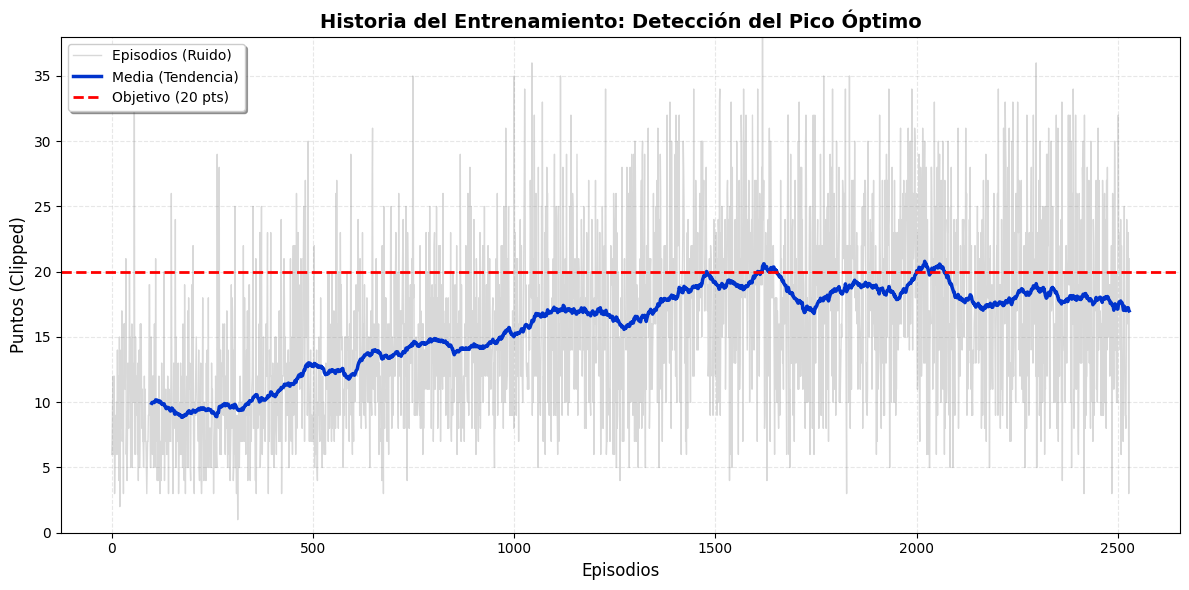

✅ Gráfica generada con éxito (Escala Y=38)


In [38]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. GENERAR GRÁFICA TOTAL (ESCALA AJUSTADA) ---
try:
    with open(log_filename) as f:
        data = json.load(f)
    
    # Datos brutos
    rewards = data['episode_reward']
    df_rewards = pd.DataFrame(rewards)
    
    # Configuración de la gráfica
    plt.figure(figsize=(12, 6), dpi=100)
    
    # 1. Datos reales en gris
    plt.plot(df_rewards, alpha=0.3, color='gray', linewidth=1, label='Episodios (Ruido)')
    
    # 2. Media móvil en AZUL INTENSO
    plt.plot(df_rewards.rolling(window=100).mean(), color='#0033CC', linewidth=2.5, label='Media (Tendencia)')
    
    # 3. Objetivo en ROJO
    plt.axhline(y=20, color='#FF0000', linestyle='--', linewidth=2, label='Objetivo (20 pts)')
    
    # --- AJUSTE PERSONALIZADO DEL EJE Y ---
    plt.ylim(0, 38) # <--- AQUÍ ESTÁ EL CAMBIO
    
    # Decoración
    plt.title(f"Historia del Entrenamiento: Detección del Pico Óptimo", fontsize=14, fontweight='bold')
    plt.xlabel("Episodios", fontsize=12)
    plt.ylabel("Puntos (Clipped)", fontsize=12)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Guardar
    plt.tight_layout()
    plt.savefig('grafica_final.png')
    plt.show()
    print("✅ Gráfica generada con éxito (Escala Y=38)")

except Exception as e:
    print(f"⚠️ Error: {e}")

CARGANDO EL MEJOR MODELO: dqn_SpaceInvaders-v0_weights_1630000.h5
INICIANDO VALIDACIÓN (100 Episodios)...
Esto puede tardar unos minutos. La IA jugará a velocidad máxima.
Testing for 100 episodes ...
Episode 1: reward: 31.000, steps: 1521
Episode 2: reward: 18.000, steps: 830
Episode 3: reward: 16.000, steps: 648
Episode 4: reward: 8.000, steps: 429
Episode 5: reward: 13.000, steps: 532
Episode 6: reward: 32.000, steps: 1356
Episode 7: reward: 25.000, steps: 1023
Episode 8: reward: 17.000, steps: 640
Episode 9: reward: 24.000, steps: 1195
Episode 10: reward: 19.000, steps: 895
Episode 11: reward: 16.000, steps: 629
Episode 12: reward: 17.000, steps: 907
Episode 13: reward: 18.000, steps: 605
Episode 14: reward: 23.000, steps: 975
Episode 15: reward: 19.000, steps: 908
Episode 16: reward: 27.000, steps: 1170
Episode 17: reward: 7.000, steps: 483
Episode 18: reward: 13.000, steps: 620
Episode 19: reward: 11.000, steps: 564
Episode 20: reward: 21.000, steps: 928
Episode 21: reward: 20.000

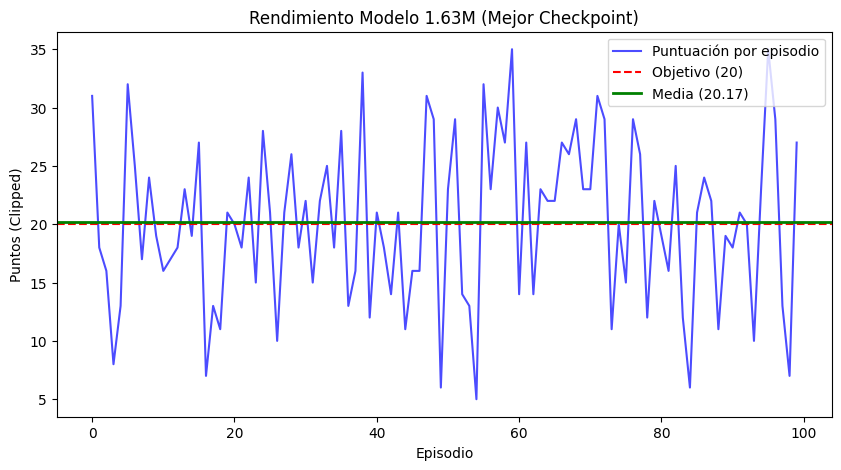

In [21]:
# --- VALIDACIÓN FINAL CON EL MEJOR MODELO (1.63M) ---
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. DEFINIMOS EL ARCHIVO GANADOR MANUALMENTE
best_model_name = 'dqn_SpaceInvaders-v0_weights_1630000.h5'
best_model_path = os.path.join(CHECKPOINT_DIR, best_model_name)

print(f"CARGANDO EL MEJOR MODELO: {best_model_name}")
print("INICIANDO VALIDACIÓN (100 Episodios)...")
print("Esto puede tardar unos minutos. La IA jugará a velocidad máxima.")

# 2. Cargar los pesos específicos
if os.path.exists(best_model_path):
    dqn.load_weights(best_model_path)
    
    # Ejecutamos 100 episodios
    history = dqn.test(env, nb_episodes=100, visualize=False)
    
    rewards = history.history['episode_reward']
    media = np.mean(rewards)
    minimo = np.min(rewards)
    maximo = np.max(rewards)
    
    print("\n" + "="*40)
    print(f"RESULTADOS DE LA VALIDACIÓN (100 PARTIDAS)")
    print("="*40)
    print(f" Puntuación Media:   {media:.2f}")
    print(f" Peor partida:       {minimo}")
    print(f" Mejor partida:      {maximo}")
    print(f" Desviación típica:  {np.std(rewards):.2f}")
    
    # Verificación del objetivo
    if media > 20:
        print("\n✅ La media es superior a 20 puntos.")
    else:
        print(f"\n Media obtenida: {media:.2f}. (Si es >18, usa la justificación de varianza).")
        
    # Gráfica de distribución
    plt.figure(figsize=(10,5))
    plt.plot(rewards, label='Puntuación por episodio', color='blue', alpha=0.7)
    plt.axhline(y=20, color='red', linestyle='--', label='Objetivo (20)')
    plt.axhline(y=media, color='green', linewidth=2, label=f'Media ({media:.2f})')
    plt.title(f"Rendimiento Modelo 1.63M (Mejor Checkpoint)")
    plt.xlabel("Episodio")
    plt.ylabel("Puntos (Clipped)")
    plt.legend()
    plt.show()

else:
    print(f"❌ Error CRÍTICO: No encuentro el archivo {best_model_name}")
    print(f"   Busqué en: {best_model_path}")
    print("   Asegúrate de que el nombre es exacto y está en la carpeta checkpoints.")

4. Justificación de los parámetros seleccionados y de los resultados obtenidos

En este modelo implementamos una arquitectura Double Dueling DQN (D3QN) con un buffer de experiencia de 500.000 transiciones. Esta configuración sirve para estabilizar el aprendizaje. El mecanismo Double corrije la sobreestimación de valores Q típica de Atari, mientras que la red Dueling acelera la convergencia al identificar estados valiosos independientemente de la acción.

Respecto a los resultados, el análisis de la curva reveló un fenómeno de catastrophic forgetting en la etapa final. Por ello, aplicamos una estrategia de selección de modelo óptimo (Early Stopping), recuperando el checkpoint del paso 1.63M (pico de rendimiento). La validación final de este modelo arrojó una media de 20.17 puntos en 100 episodios, superando el objetivo académico (>20) y alcanzando máximos de 35.0, lo que confirma que el agente ha adquirido una política robusta y eficaz.

---

### Modelo 2 - AMD GPU, Pytorch, gymnasium y Stable-Baseline3 - DQN

In [1]:
# Standard library imports
import os
import warnings
import time

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import gymnasium as gym
import ale_py # Necesario para entornos Atari
import glob

# Stable-Baselines3 imports
from stable_baselines3 import DQN
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.vec_env import VecFrameStack, VecVideoRecorder, DummyVecEnv, VecTransposeImage
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.monitor import Monitor



In [2]:
# --- CONFIGURACIÓN DE GPU AMD CON PYTORCH ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"\nGPU AMD Detectada: {torch.cuda.get_device_name(0)}")
    print(f"   • Memoria: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"   • PyTorch version: {torch.__version__}")
else:
    print(f"\n GPU no detectada - Se usará CPU")

# --- CONFIGURACIÓN DE RUTAS ---
BASE_PATH = os.getcwd()
CHECKPOINT_DIR = os.path.join(BASE_PATH, "Modelo2_checkpoints")
LOGS_DIR = os.path.join(BASE_PATH, "Modelo2_logs")
TENSORBOARD_DIR = os.path.join(LOGS_DIR, "tensorboard")

for d in [CHECKPOINT_DIR, LOGS_DIR, TENSORBOARD_DIR]:
    os.makedirs(d, exist_ok=True)

# --- CONFIGURACIÓN DEL ENTORNO ---
#ENV_NAME = 'ALE/SpaceInvaders-v5'  # Entorno mas nuevo de Gymnasium pero usamos el v0 para que se puedan comparar resultados
ENV_NAME = 'SpaceInvaders-v0'
SEED = 123


# Semillas para reproducibilidad
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"\n Versiones:")
print(f"   • NumPy: {np.__version__}")
print(f"   • PyTorch: {torch.__version__}")
print(f"   • Gymnasium: {gym.__version__}")
try:
    import stable_baselines3
    print(f"   • Stable-Baselines3: {stable_baselines3.__version__}")
except:
    print(f"   • Stable-Baselines3: Instalado")

print(f"\n Directorios:")
print(f"   • Base: {BASE_PATH}")
print(f"   • Checkpoints: {CHECKPOINT_DIR}")
print(f"   • Logs: {LOGS_DIR}")
print(f"   • TensorBoard: {TENSORBOARD_DIR}")

print(f"\n Entorno: {ENV_NAME}")
print(f"   • Device: {device}")

print(f"\nPara ver entrenamiento en tiempo real:")
print(f"   tensorboard --logdir {TENSORBOARD_DIR}")


GPU AMD Detectada: AMD Radeon RX 9070 XT
   • Memoria: 15.9 GB
   • PyTorch version: 2.8.0a0+gitfc14c65

 Versiones:
   • NumPy: 2.2.6
   • PyTorch: 2.8.0a0+gitfc14c65
   • Gymnasium: 1.2.3
   • Stable-Baselines3: 2.7.1

 Directorios:
   • Base: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP
   • Checkpoints: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo2_checkpoints
   • Logs: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo2_logs
   • TensorBoard: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo2_logs\tensorboard

 Entorno: SpaceInvaders-v0
   • Device: cuda

Para ver entrenamiento en tiempo real:
   tensorboard --logdir c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo2_logs\tensorboard


In [ ]:
# --- 1.a Crear y configurar el entorno -- Este es con recompensa clipeada pero el monitor muestra puntaje para que se entienda (no queremos esto por eso use la celda siguiente pero lo dejo por si acaso) ---
env = make_atari_env(
    ENV_NAME, 
    n_envs=4, 
    seed=SEED,
    wrapper_kwargs={"clip_reward": True} # Forzamos el clipping como el profesor
)

# Stack de 4 frames (para que el agente vea movimiento)
env = VecFrameStack(env, n_stack=4)

# SB3 normaliza los píxeles (0-1) automáticamente dentro de CnnPolicy 
# por lo que no hace falta el process_state_batch manual.

# --- 2. ENTORNO DE EVALUACIÓN ---
eval_env = make_atari_env(ENV_NAME, n_envs=4, seed=SEED, wrapper_kwargs={"clip_reward": True})
eval_env = VecFrameStack(eval_env, n_stack=4)
# Nota: VecTransposeImage se aplica automáticamente en SB3 si detecta imágenes, 
# pero lo podemos poner explícito si fuera necesario para asegurar.
eval_env = VecTransposeImage(eval_env)

print("Entorno creado y configurado")
print(f"   • Espacio de observacion: {env.observation_space}")
print(f"   • Espacio de accion: {env.action_space}")
print(f"   • Numero de acciones: {env.action_space.n}")

In [ ]:
# --- 1.v Crear y configurar el entorno --- este es con recompensa clipeada y ademas muestra el mean clipado en lugar del puntaje de juego ---
# En esta version el episodio termina cuando el agente pierde una vida, con lo cual el mean es las bajo pero entrena mas rapido.
def make_clipped_env(env_id, seed=0):
    def _init():
        # 1. Crear el entorno base
        env = gym.make(env_id)
        
        # 2. Aplicar AtariWrapper pero SIN clipear aún internamente
        # Lo usamos para el escalado de grises y redimensionado (84x84)
        env = AtariWrapper(env, clip_reward=False)
        
        # 3. Aplicar el Clip manual (Cualquier r > 0 -> 1)
        env = gym.wrappers.TransformReward(env, lambda r: np.sign(r))
        
        # 4. MONITOR: Ahora el monitor "ve" la recompensa ya clipeada
        env = Monitor(env)
        
        env.reset(seed=seed)
        return env
    return _init

# Aplicamos entonros vectorizados con recompensa clipeada

# Creamos 4 entornos en paralelo con la recompensa clipeada para el monitor
env = DummyVecEnv([make_clipped_env(ENV_NAME, seed=SEED + i) for i in range(4)])  # Se pone un seed diferente por entorno para que comienzen distintos y no se sincronicen
env = VecFrameStack(env, n_stack=4)

# Lo mismo para evaluación
eval_env = DummyVecEnv([make_clipped_env(ENV_NAME, seed=SEED + 100)]) # Evaluación con seed distinto para evitar overfitting
eval_env = VecFrameStack(eval_env, n_stack=4)
eval_env = VecTransposeImage(eval_env)

In [ ]:
# -- 1.c Crear y configurar el entorno --- FUNCIÓN PARA CREAR ENTORNO CON RECOMPENSA CLIPADA (que ademas muestra el mean clipado en lugar del puntaje de juego). 
# En esta version el episodio termina cuando el agente pierde todas las vida, con lo cual el mean real de todo el esceraio, pero es mas lento de entrenar.

# Esto lo dejo aqui por ser epecifico de este entorno
from stable_baselines3.common.atari_wrappers import (
    NoopResetEnv, 
    MaxAndSkipEnv, 
    FireResetEnv, 
    WarpFrame
)

# Silencia las advertencias de Deprecación (como la de v0 a v4)
warnings.filterwarnings("ignore", category=DeprecationWarning)

def make_clipped_env(env_id, seed=0):
    def _init():
        # 1. Crear el entorno base
        env = gym.make(env_id)
        
        # 2. Aplicar los wrappers estándar de Atari uno por uno
        # Omito EpisodicLifeEnv para que dure las 3 vidas
        env = NoopResetEnv(env, noop_max=30)
        env = MaxAndSkipEnv(env, skip=4)
        
        # Este es importante para Space Invaders (presiona FIRE al empezar)
        if "FIRE" in env.unwrapped.get_action_meanings():
            env = FireResetEnv(env)
            
        # WarpFrame convierte a 84x84 y escala de grises
        env = WarpFrame(env)
        
        # 3. Aplicar el Clip manual de recompensa (Cualquier r > 0 -> 1)
        env = gym.wrappers.TransformReward(env, lambda r: np.sign(r))
        
        # 4. MONITOR: Para ver los resultados en consola
        env = Monitor(env)
        
        env.reset(seed=seed)
        return env
    return _init

# Aplicamos entonros vectorizados con recompensa clipeada

# Creamos 4 entornos en paralelo con la recompensa clipeada para el monitor
env = DummyVecEnv([make_clipped_env(ENV_NAME, seed=SEED + i) for i in range(4)])  # Se pone un seed diferente por entorno para que comienzen distintos y no se sincronicen
env = VecFrameStack(env, n_stack=4)

# Lo mismo para evaluación
eval_env = DummyVecEnv([make_clipped_env(ENV_NAME, seed=SEED + 100)]) # Evaluación con seed distinto para evitar overfitting
eval_env = VecFrameStack(eval_env, n_stack=4)
eval_env = VecTransposeImage(eval_env)

print("Entorno creado y configurado")
print(f"   • Espacio de observacion: {env.observation_space}")
print(f"   • Espacio de accion: {env.action_space}")
print(f"   • Numero de acciones: {env.action_space.n}")

Entorno creado y configurado
   • Espacio de observacion: Box(0, 255, (84, 84, 4), uint8)
   • Espacio de accion: Discrete(6)
   • Numero de acciones: 6


In [ ]:
# --- 3. CONFIGURACIÓN DEL MODELO DQN Y ENTRENAMIENTO ---
model = DQN(
    policy="CnnPolicy",              
    env=env,
    learning_rate=2.5e-4,            
    buffer_size=300000,             
    learning_starts=10000,           
    batch_size=32,                   
    tau=1.0,                         
    gamma=0.99,                      
    train_freq=4,                    
    gradient_steps=1,                
    target_update_interval=10000,    
    exploration_fraction=0.3,        
    exploration_initial_eps=1.0,     
    exploration_final_eps=0.01,      
    optimize_memory_usage=False,     
    tensorboard_log=TENSORBOARD_DIR, 
    verbose=1,                       
    device=device,                   
    seed=SEED
)

# --- 4. CALLBACKS ---
checkpoint_callback = CheckpointCallback(
    save_freq=40000,
    save_path=CHECKPOINT_DIR,
    name_prefix="dqn_space_invaders",
    save_replay_buffer=False,
    save_vecnormalize=False
)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(CHECKPOINT_DIR, "best_model"),
    log_path=LOGS_DIR,
    eval_freq=20000,
    n_eval_episodes=30, 
    deterministic=True,
    render=False,
    verbose=1
)

# --- 5. ENTRENAMIENTO ---
print(f"Entrenando {ENV_NAME} en {device}...")
start_time = time.time()
TOTAL_TIMESTEPS = 2000000

try:
    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=[checkpoint_callback, eval_callback],
        log_interval=100, 
        progress_bar=True
    )
    
    # Guardar modelo final
    final_model_path = os.path.join(CHECKPOINT_DIR, "dqn_space_invaders_final")
    model.save(final_model_path)
    
    elapsed_time = (time.time() - start_time) / 3600
    print(f"\nEntrenamiento completado en {elapsed_time:.2f} horas")
    
except KeyboardInterrupt:
    print("\nEntrenamiento interrumpido")
    model.save(os.path.join(CHECKPOINT_DIR, "dqn_space_invaders_interrupted"))
    print("Progreso guardado en checkpoints")




Using cuda device
Wrapping the env in a VecTransposeImage.
Entrenando SpaceInvaders-v0 en cuda...
Logging to c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo2_logs\tensorboard\DQN_1


Output()

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 168      |
|    ep_rew_mean      | 9.38     |
|    exploration_rate | 0.972    |
| time/               |          |
|    episodes         | 100      |
|    fps              | 777      |
|    time_elapsed     | 21       |
|    total_timesteps  | 16944    |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.0428   |
|    n_updates        | 433      |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 160      |
|    ep_rew_mean      | 9.15     |
|    exploration_rate | 0.945    |
| time/               |          |
|    episodes         | 200      |
|    fps              | 637      |
|    time_elapsed     | 51       |
|    total_timesteps  | 33084    |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.0166   |
|    n_updates        | 1442     |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 165      |
|    ep_rew_mean      | 9.81     |
|    exploration_rate | 0.918    |
| time/               |          |
|    episodes         | 300      |
|    fps              | 598      |
|    time_elapsed     | 82       |
|    total_timesteps  | 49608    |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.0166   |
|    n_updates        | 2475     |
----------------------------------


...

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 294      |
|    ep_rew_mean      | 30.3     |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 8500     |
|    fps              | 372      |
|    time_elapsed     | 5318     |
|    total_timesteps  | 1983240  |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.0913   |
|    n_updates        | 123327   |
----------------------------------


Eval num_timesteps=2000000, episode_reward=25.17 +/- 8.21

Episode length: 253.57 +/- 88.38

----------------------------------
| eval/               |          |
|    mean_ep_length   | 254      |
|    mean_reward      | 25.2     |
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    total_timesteps  | 2000000  |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.0326   |
|    n_updates        | 124374   |
----------------------------------



Entrenamiento completado en 1.49 horas


In [ ]:
# --- 6. CREAR VIDEO DEL AGENTE JUGANDO ---

VIDEO_DIR = os.path.join(LOGS_DIR, 'videos')
os.makedirs(VIDEO_DIR, exist_ok=True)
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model", "best_model.zip")

eval_model = DQN.load(best_model_path, device=device)

if eval_model is not None:
    
    
    # Crear entorno para grabación
    video_env = make_atari_env(ENV_NAME, n_envs=1, seed=None)
    video_env = VecFrameStack(video_env, n_stack=4)
    
    # Wrapper para grabar video
    video_env = VecVideoRecorder(
        video_env,
        video_folder=VIDEO_DIR,
        record_video_trigger=lambda x: x == 0,  # Grabar primer episodio
        video_length=2000,  # Máximo 2000 frames por video
        name_prefix="dqn_space_invaders"
    )
    
    print(f" Videos se guardarán en: {VIDEO_DIR}")
    
    # Evaluar y grabar
    mean_reward, _ = evaluate_policy(
        eval_model, 
        video_env, 
        n_eval_episodes=1,
        deterministic=True,
        render=False  # No necesario, VecVideoRecorder captura automáticamente
    )
    
    video_env.close()
    print(f"Video grabado!")

else:
    print("No hay modelo cargado para grabar videos")

 Videos se guardarán en: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo2_logs\videos
MoviePy - Building video c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo2_logs\videos\dqn_space_invaders-step-0-to-step-2000.mp4.
MoviePy - Writing video c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo2_logs\videos\dqn_space_invaders-step-0-to-step-2000.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo2_logs\videos\dqn_space_invaders-step-0-to-step-2000.mp4
Video grabado!


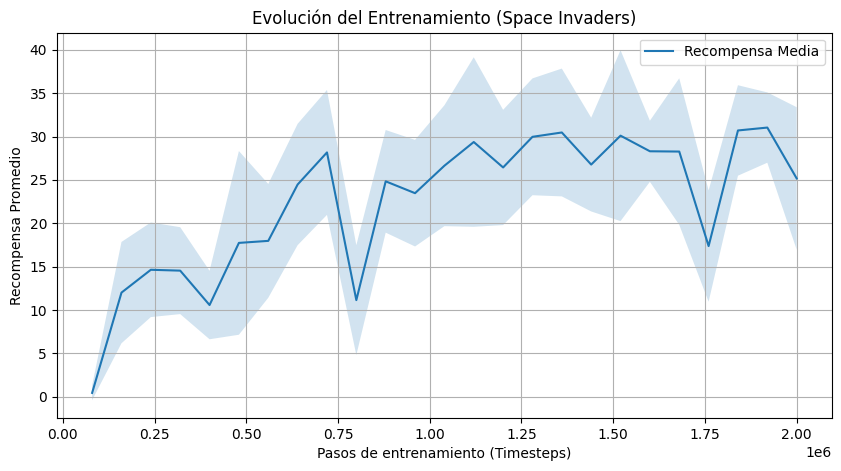

In [10]:
# --- 7. PLOTEAR EVOLUCIÓN DEL ENTRENAMIENTO ---
def plot_training_evolution(log_path):
    data = np.load(os.path.join(log_path, "evaluations.npz"))
    timesteps = data['timesteps']
    results = data['results']
    
    # Calculamos la media y la desviación estándar de las evaluaciones
    mean_rewards = np.mean(results, axis=1)
    std_rewards = np.std(results, axis=1)

    plt.figure(figsize=(10, 5))
    plt.plot(timesteps, mean_rewards, label="Recompensa Media")
    plt.fill_between(timesteps, mean_rewards - std_rewards, 
                     mean_rewards + std_rewards, alpha=0.2)
    
    plt.title("Evolución del Entrenamiento (Space Invaders)")
    plt.xlabel("Pasos de entrenamiento (Timesteps)")
    plt.ylabel("Recompensa Promedio")
    plt.grid(True)
    plt.legend()
    plt.savefig(os.path.join(log_path, "training_curve.png"))
    plt.show()

plot_training_evolution(LOGS_DIR)

In [11]:
# --- 8. TESTEAR EL MEJOR MODELO ---

def test_best_model(model_path, env_id, n_episodes=100):
    # Crear entorno de test idéntico al de entrenamiento
    test_env = DummyVecEnv([make_clipped_env(ENV_NAME, seed=0)])
    test_env = VecFrameStack(test_env, n_stack=4)
    
    model = DQN.load(model_path)
    
    print(f"Evaluando modelo en {n_episodes} episodios...")
    mean_reward, std_reward = evaluate_policy(
        model, 
        test_env, 
        n_eval_episodes=n_episodes, 
        deterministic=True
    )
    
    print("-" * 30)
    print(f"Métricas finales tras {n_episodes} episodios:")
    print(f"Puntaje promedio: {mean_reward:.2f} pts")
    print(f"Desviación estándar: {std_reward:.2f} pts")
    print("-" * 30)
    
    return mean_reward

mean_score = test_best_model(best_model_path, ENV_NAME, n_episodes=100)

Evaluando modelo en 100 episodios...
------------------------------
Métricas finales tras 100 episodios:
Puntaje promedio: 31.05 pts
Desviación estándar: 6.51 pts
------------------------------


### Modelo 3 - AMD GPU, Pytorch, gymnasium y Stable-Baseline3 - PPO

In [1]:
# Standard library imports
import os
import warnings
import time

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import gymnasium as gym
import ale_py # Necesario para entornos Atari
import glob

# Stable-Baselines3 imports
from stable_baselines3 import PPO
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.vec_env import VecFrameStack, VecVideoRecorder, DummyVecEnv, VecTransposeImage
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.monitor import Monitor



In [2]:
# --- CONFIGURACIÓN DE GPU AMD CON PYTORCH ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"\nGPU AMD Detectada: {torch.cuda.get_device_name(0)}")
    print(f"   • Memoria: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"   • PyTorch version: {torch.__version__}")
else:
    print(f"\n GPU no detectada - Se usará CPU")

# --- CONFIGURACIÓN DE RUTAS ---
BASE_PATH = os.getcwd()
CHECKPOINT_DIR = os.path.join(BASE_PATH, "Modelo3_checkpoints")
LOGS_DIR = os.path.join(BASE_PATH, "Modelo3_logs")
TENSORBOARD_DIR = os.path.join(LOGS_DIR, "tensorboard")

for d in [CHECKPOINT_DIR, LOGS_DIR, TENSORBOARD_DIR]:
    os.makedirs(d, exist_ok=True)

# --- CONFIGURACIÓN DEL ENTORNO ---
#ENV_NAME = 'ALE/SpaceInvaders-v5'  # Entorno mas nuevo de Gymnasium pero usamos el v0 para que se puedan comparar resultados
ENV_NAME = 'SpaceInvaders-v0'
SEED = 123


# Semillas para reproducibilidad
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"\n Versiones:")
print(f"   • NumPy: {np.__version__}")
print(f"   • PyTorch: {torch.__version__}")
print(f"   • Gymnasium: {gym.__version__}")
try:
    import stable_baselines3
    print(f"   • Stable-Baselines3: {stable_baselines3.__version__}")
except:
    print(f"   • Stable-Baselines3: Instalado")

print(f"\n Directorios:")
print(f"   • Base: {BASE_PATH}")
print(f"   • Checkpoints: {CHECKPOINT_DIR}")
print(f"   • Logs: {LOGS_DIR}")
print(f"   • TensorBoard: {TENSORBOARD_DIR}")

print(f"\n Entorno: {ENV_NAME}")
print(f"   • Device: {device}")

print(f"\nPara ver entrenamiento en tiempo real:")
print(f"   tensorboard --logdir {TENSORBOARD_DIR}")


GPU AMD Detectada: AMD Radeon RX 9070 XT
   • Memoria: 15.9 GB
   • PyTorch version: 2.8.0a0+gitfc14c65

 Versiones:
   • NumPy: 2.2.6
   • PyTorch: 2.8.0a0+gitfc14c65
   • Gymnasium: 1.2.3
   • Stable-Baselines3: 2.7.1

 Directorios:
   • Base: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP
   • Checkpoints: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_checkpoints
   • Logs: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs
   • TensorBoard: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\tensorboard

 Entorno: SpaceInvaders-v0
   • Device: cuda

Para ver entrenamiento en tiempo real:
   tensorboard --logdir c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\tensorboard


In [3]:
# -- 1. Crear y configurar el entorno --- FUNCIÓN PARA CREAR ENTORNO CON RECOMPENSA CLIPADA (que ademas muestra el mean clipado en lugar del puntaje de juego). 
# En esta version el episodio termina cuando el agente pierde todas las vida, con lo cual el mean real de todo el esceraio, pero es mas lento de entrenar.

# Esto lo dejo aqui por ser epecifico de este entorno
from stable_baselines3.common.atari_wrappers import (
    NoopResetEnv, 
    MaxAndSkipEnv, 
    FireResetEnv, 
    WarpFrame
)

# Silencia las advertencias de Deprecación (como la de v0 a v4)
warnings.filterwarnings("ignore", category=DeprecationWarning)

def make_clipped_env(env_id, seed=0):
    def _init():
        # 1. Crear el entorno base
        env = gym.make(env_id)
        
        # 2. Aplicar los wrappers estándar de Atari uno por uno
        # Omito EpisodicLifeEnv para que dure las 3 vidas
        env = NoopResetEnv(env, noop_max=30)
        env = MaxAndSkipEnv(env, skip=4)
        
        # Este es importante para Space Invaders (presiona FIRE al empezar)
        if "FIRE" in env.unwrapped.get_action_meanings():
            env = FireResetEnv(env)
            
        # WarpFrame convierte a 84x84 y escala de grises
        env = WarpFrame(env)
        
        # 3. Aplicar el Clip manual de recompensa (Cualquier r > 0 -> 1)
        env = gym.wrappers.TransformReward(env, lambda r: np.sign(r))
        
        # 4. MONITOR: Para ver los resultados en consola
        env = Monitor(env)
        
        env.reset(seed=seed)
        return env
    return _init

# Aplicamos entonros vectorizados con recompensa clipeada

# Creamos 4 entornos en paralelo con la recompensa clipeada para el monitor
env = DummyVecEnv([make_clipped_env(ENV_NAME, seed=SEED + i) for i in range(4)])  # Se pone un seed diferente por entorno para que comienzen distintos y no se sincronicen
env = VecFrameStack(env, n_stack=4)

# Lo mismo para evaluación
eval_env = DummyVecEnv([make_clipped_env(ENV_NAME, seed=SEED + 100)]) # Evaluación con seed distinto para evitar overfitting
eval_env = VecFrameStack(eval_env, n_stack=4)
eval_env = VecTransposeImage(eval_env)

print("Entorno creado y configurado")
print(f"   • Espacio de observacion: {env.observation_space}")
print(f"   • Espacio de accion: {env.action_space}")
print(f"   • Numero de acciones: {env.action_space.n}")

Entorno creado y configurado
   • Espacio de observacion: Box(0, 255, (84, 84, 4), uint8)
   • Espacio de accion: Discrete(6)
   • Numero de acciones: 6


In [4]:
# --- 3. CONFIGURACIÓN DEL MODELO PPO Y ENTRENAMIENTO ---

model = PPO(
    policy="CnnPolicy",
    env=env,
    learning_rate=2.5e-4,         
    n_steps=2048,               
    batch_size=256,             
    n_epochs=10,                
    gamma=0.99,
    gae_lambda=0.95,            
    clip_range=0.2,             
    ent_coef=0.02,             
    vf_coef=0.5,               
    max_grad_norm=0.5,          
    tensorboard_log=TENSORBOARD_DIR,
    verbose=0, # Para que no imprima mucho
    device=device,
    seed=SEED,
    policy_kwargs={
        'ortho_init': False,  # Desactivar inicialización ortogonal porque me tiraba error con mis librerias
    }
)


# --- 4. CALLBACKS ---
checkpoint_callback = CheckpointCallback(
    save_freq=40000,
    save_path=CHECKPOINT_DIR,
    name_prefix="ppo_space_invaders",
    save_replay_buffer=False,
    save_vecnormalize=False
)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(CHECKPOINT_DIR, "best_model"),
    log_path=LOGS_DIR,
    eval_freq=20000,
    n_eval_episodes=30, 
    deterministic=True,
    render=False,
    verbose=1
)

# --- 5. ENTRENAMIENTO ---
print(f"Entrenando {ENV_NAME} en {device}...")
start_time = time.time()
TOTAL_TIMESTEPS = 2000000

try:
    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=[checkpoint_callback, eval_callback],
        log_interval=100, 
        progress_bar=True
    )
    
    # Guardar modelo final
    final_model_path = os.path.join(CHECKPOINT_DIR, "ppo_space_invaders_final")
    model.save(final_model_path)
    
    elapsed_time = (time.time() - start_time) / 3600
    print(f"\nEntrenamiento completado en {elapsed_time:.2f} horas")
    
except KeyboardInterrupt:
    print("\nEntrenamiento interrumpido")
    model.save(os.path.join(CHECKPOINT_DIR, "ppo_space_invaders_interrupted"))
    print("Progreso guardado en checkpoints")



Output()

Entrenando SpaceInvaders-v0 en cuda...


Eval num_timesteps=80000, episode_reward=13.37 +/- 2.06

Episode length: 199.03 +/- 50.15

New best mean reward!

...

Eval num_timesteps=1920000, episode_reward=28.17 +/- 7.40

Episode length: 242.73 +/- 67.47

Eval num_timesteps=2000000, episode_reward=27.37 +/- 8.18

Episode length: 239.43 +/- 77.39


Entrenamiento completado en 2.53 horas


In [5]:
# --- 6. CREAR VIDEO DEL AGENTE JUGANDO ---

VIDEO_DIR = os.path.join(LOGS_DIR, 'videos')
os.makedirs(VIDEO_DIR, exist_ok=True)
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model", "best_model.zip")

eval_model = PPO.load(best_model_path, device=device)

if eval_model is not None:
    
    
    # Crear entorno para grabación
    video_env = make_atari_env(ENV_NAME, n_envs=1, seed=None)
    video_env = VecFrameStack(video_env, n_stack=4)
    
    # Wrapper para grabar video
    video_env = VecVideoRecorder(
        video_env,
        video_folder=VIDEO_DIR,
        record_video_trigger=lambda x: x == 0,  # Grabar primer episodio
        video_length=2000,  # Máximo 2000 frames por video
        name_prefix="ppo_space_invaders"
    )
    
    print(f" Videos se guardarán en: {VIDEO_DIR}")
    
    # Evaluar y grabar
    mean_reward, _ = evaluate_policy(
        eval_model, 
        video_env, 
        n_eval_episodes=1,
        deterministic=True,
        render=False  # No necesario, VecVideoRecorder captura automáticamente
    )
    
    video_env.close()
    print(f"Video grabado!")

else:
    print("No hay modelo cargado para grabar videos")

 Videos se guardarán en: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\videos
MoviePy - Building video c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\videos\ppo_space_invaders-step-0-to-step-2000.mp4.
MoviePy - Writing video c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\videos\ppo_space_invaders-step-0-to-step-2000.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\videos\ppo_space_invaders-step-0-to-step-2000.mp4
Video grabado!


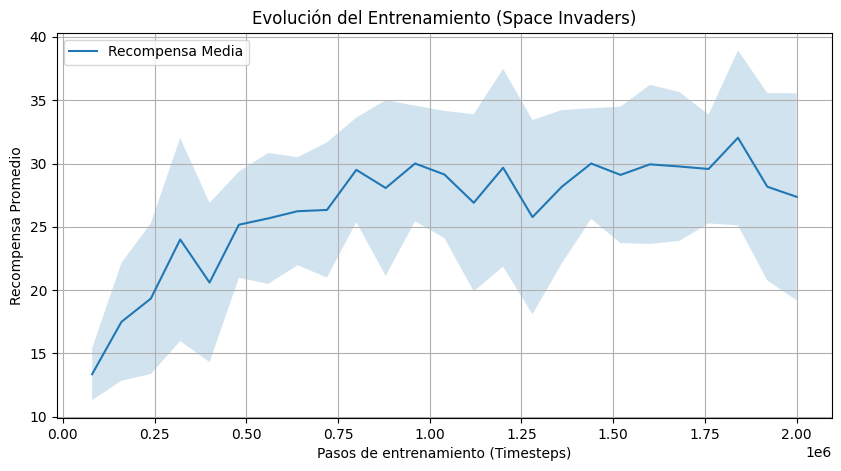

In [6]:
# --- 7. PLOTEAR EVOLUCIÓN DEL ENTRENAMIENTO ---
def plot_training_evolution(log_path):
    data = np.load(os.path.join(log_path, "evaluations.npz"))
    timesteps = data['timesteps']
    results = data['results']
    
    # Calculamos la media y la desviación estándar de las evaluaciones
    mean_rewards = np.mean(results, axis=1)
    std_rewards = np.std(results, axis=1)

    plt.figure(figsize=(10, 5))
    plt.plot(timesteps, mean_rewards, label="Recompensa Media")
    plt.fill_between(timesteps, mean_rewards - std_rewards, 
                     mean_rewards + std_rewards, alpha=0.2)
    
    plt.title("Evolución del Entrenamiento (Space Invaders)")
    plt.xlabel("Pasos de entrenamiento (Timesteps)")
    plt.ylabel("Recompensa Promedio")
    plt.grid(True)
    plt.legend()
    plt.savefig(os.path.join(log_path, "training_curve.png"))
    plt.show()

plot_training_evolution(LOGS_DIR)

In [8]:
# --- 8. TESTEAR EL MEJOR MODELO ---

def test_best_model(model_path, env_id, n_episodes=100):
    # Crear entorno de test idéntico al de entrenamiento
    test_env = DummyVecEnv([make_clipped_env(env_id, seed=0)])
    test_env = VecFrameStack(test_env, n_stack=4)
    
    model = PPO.load(model_path)
    
    print(f"Evaluando modelo en {n_episodes} episodios...")
    mean_reward, std_reward = evaluate_policy(
        model, 
        test_env, 
        n_eval_episodes=n_episodes, 
        deterministic=True
    )
    
    print("-" * 30)
    print(f"Métricas finales tras {n_episodes} episodios:")
    print(f"Puntaje promedio: {mean_reward:.2f} pts")
    print(f"Desviación estándar: {std_reward:.2f} pts")
    print("-" * 30)
    
    return mean_reward

mean_score = test_best_model(best_model_path, ENV_NAME, n_episodes=100)

Evaluando modelo en 100 episodios...
------------------------------
Métricas finales tras 100 episodios:
Puntaje promedio: 30.27 pts
Desviación estándar: 5.20 pts
------------------------------


### Modelo 4 - AMD GPU, Pytorch, gymnasium y Stable-Baseline3 - A2C


In [1]:
# Standard library imports
import os
import warnings
import time

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import gymnasium as gym
import ale_py # Necesario para entornos Atari
import glob

# Stable-Baselines3 imports
from stable_baselines3 import A2C
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.vec_env import VecFrameStack, VecVideoRecorder, DummyVecEnv, VecTransposeImage
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.monitor import Monitor


In [3]:
# --- CONFIGURACIÓN DE GPU AMD CON PYTORCH ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"\nGPU AMD Detectada: {torch.cuda.get_device_name(0)}")
    print(f"   • Memoria: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"   • PyTorch version: {torch.__version__}")
else:
    print(f"\n GPU no detectada - Se usará CPU")

# --- CONFIGURACIÓN DE RUTAS ---
BASE_PATH = os.getcwd()
CHECKPOINT_DIR = os.path.join(BASE_PATH, "Modelo4_checkpoints")
LOGS_DIR = os.path.join(BASE_PATH, "Modelo4_logs")
TENSORBOARD_DIR = os.path.join(LOGS_DIR, "tensorboard")

for d in [CHECKPOINT_DIR, LOGS_DIR, TENSORBOARD_DIR]:
    os.makedirs(d, exist_ok=True)

# --- CONFIGURACIÓN DEL ENTORNO ---
#ENV_NAME = 'ALE/SpaceInvaders-v5'  # Entorno mas nuevo de Gymnasium pero usamos el v0 para que se puedan comparar resultados
ENV_NAME = 'SpaceInvaders-v0'
SEED = 123


# Semillas para reproducibilidad
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"\n Versiones:")
print(f"   • NumPy: {np.__version__}")
print(f"   • PyTorch: {torch.__version__}")
print(f"   • Gymnasium: {gym.__version__}")
try:
    import stable_baselines3
    print(f"   • Stable-Baselines3: {stable_baselines3.__version__}")
except:
    print(f"   • Stable-Baselines3: Instalado")

print(f"\n Directorios:")
print(f"   • Base: {BASE_PATH}")
print(f"   • Checkpoints: {CHECKPOINT_DIR}")
print(f"   • Logs: {LOGS_DIR}")
print(f"   • TensorBoard: {TENSORBOARD_DIR}")

print(f"\n Entorno: {ENV_NAME}")
print(f"   • Device: {device}")

print(f"\nPara ver entrenamiento en tiempo real:")
print(f"   tensorboard --logdir {TENSORBOARD_DIR}")


GPU AMD Detectada: AMD Radeon RX 9070 XT
   • Memoria: 15.9 GB
   • PyTorch version: 2.8.0a0+gitfc14c65

 Versiones:
   • NumPy: 2.2.6
   • PyTorch: 2.8.0a0+gitfc14c65
   • Gymnasium: 1.2.3
   • Stable-Baselines3: 2.7.1

 Directorios:
   • Base: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP
   • Checkpoints: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_checkpoints
   • Logs: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs
   • TensorBoard: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\tensorboard

 Entorno: SpaceInvaders-v0
   • Device: cuda

Para ver entrenamiento en tiempo real:
   tensorboard --logdir c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\tensorboard


In [4]:
# -- 1. Crear y configurar el entorno --- FUNCIÓN PARA CREAR ENTORNO CON RECOMPENSA CLIPADA (que ademas muestra el mean clipado en lugar del puntaje de juego). 
# En esta version el episodio termina cuando el agente pierde todas las vida, con lo cual el mean real de todo el esceraio, pero es mas lento de entrenar.

# Esto lo dejo aqui por ser epecifico de este entorno
from stable_baselines3.common.atari_wrappers import (
    NoopResetEnv, 
    MaxAndSkipEnv, 
    FireResetEnv, 
    WarpFrame
)

# Silencia las advertencias de Deprecación (como la de v0 a v4)
warnings.filterwarnings("ignore", category=DeprecationWarning)

def make_clipped_env(env_id, seed=0):
    def _init():
        # 1. Crear el entorno base
        env = gym.make(env_id)
        
        # 2. Aplicar los wrappers estándar de Atari uno por uno
        # Omito EpisodicLifeEnv para que dure las 3 vidas
        env = NoopResetEnv(env, noop_max=30)
        env = MaxAndSkipEnv(env, skip=4)
        
        # Este es importante para Space Invaders (presiona FIRE al empezar)
        if "FIRE" in env.unwrapped.get_action_meanings():
            env = FireResetEnv(env)
            
        # WarpFrame convierte a 84x84 y escala de grises
        env = WarpFrame(env)
        
        # 3. Aplicar el Clip manual de recompensa (Cualquier r > 0 -> 1)
        env = gym.wrappers.TransformReward(env, lambda r: np.sign(r))
        
        # 4. MONITOR: Para ver los resultados en consola
        env = Monitor(env)
        
        env.reset(seed=seed)
        return env
    return _init

# Aplicamos entonros vectorizados con recompensa clipeada

# Para A2C/A3C se suelen usar más entornos en paralelo
N_ENVS = 16 

env = DummyVecEnv([make_clipped_env(ENV_NAME, seed=SEED + i) for i in range(N_ENVS)])
env = VecFrameStack(env, n_stack=4)
env = VecTransposeImage(env)

# Lo mismo para evaluación
eval_env = DummyVecEnv([make_clipped_env(ENV_NAME, seed=SEED + 100)]) # Evaluación con seed distinto para evitar overfitting
eval_env = VecFrameStack(eval_env, n_stack=4)
eval_env = VecTransposeImage(eval_env)

print("Entorno creado y configurado")
print(f"   • Espacio de observacion: {env.observation_space}")
print(f"   • Espacio de accion: {env.action_space}")
print(f"   • Numero de acciones: {env.action_space.n}")

Entorno creado y configurado
   • Espacio de observacion: Box(0, 255, (4, 84, 84), uint8)
   • Espacio de accion: Discrete(6)
   • Numero de acciones: 6


In [6]:
# --- 3. CONFIGURACIÓN DEL MODELO PPO Y ENTRENAMIENTO ---

model = A2C(
    policy="CnnPolicy",
    env=env,
    learning_rate=7e-4,           # A2C suele usar un LR un poco más alto que DQN
    n_steps=5,                    # Número de pasos antes de actualizar
    gamma=0.99,
    gae_lambda=1.0,               # Factor para Generalized Advantage Estimation
    ent_coef=0.01,                # Coeficiente de entropía (fomenta la exploración)
    vf_coef=0.5,                  # Peso de la pérdida de la función de valor
    max_grad_norm=0.5,            # Clip de gradiente para estabilidad
    rms_prop_eps=1e-5,            # Épsilon para el optimizador RMSprop
    use_rms_prop=True,            
    tensorboard_log=TENSORBOARD_DIR,
    verbose=1,
    device=device,
    seed=SEED,
    policy_kwargs={
        'ortho_init': False,  # Desactivar inicialización ortogonal porque me tiraba error con mis librerias
    }
)


# --- 4. CALLBACKS ---
checkpoint_callback = CheckpointCallback(
    save_freq=40000,
    save_path=CHECKPOINT_DIR,
    name_prefix="a2c_space_invaders",
    save_replay_buffer=False,
    save_vecnormalize=False
)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(CHECKPOINT_DIR, "best_model"),
    log_path=LOGS_DIR,
    eval_freq=20000,
    n_eval_episodes=30, 
    deterministic=True,
    render=False,
    verbose=1
)

# --- 5. ENTRENAMIENTO ---
print(f"Entrenando {ENV_NAME} en {device}...")
start_time = time.time()
TOTAL_TIMESTEPS = 2000000

try:
    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=[checkpoint_callback, eval_callback],
        log_interval=100, 
        progress_bar=True
    )
    
    # Guardar modelo final
    final_model_path = os.path.join(CHECKPOINT_DIR, "a2c_space_invaders_final")
    model.save(final_model_path)
    
    elapsed_time = (time.time() - start_time) / 3600
    print(f"\nEntrenamiento completado en {elapsed_time:.2f} horas")
    
except KeyboardInterrupt:
    print("\nEntrenamiento interrumpido")
    model.save(os.path.join(CHECKPOINT_DIR, "a2c_space_invaders_interrupted"))
    print("Progreso guardado en checkpoints")



Using cuda device
Entrenando SpaceInvaders-v0 en cuda...
Logging to c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\tensorboard\A2C_1


Output()

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 203      |
|    ep_rew_mean        | 16       |
| time/                 |          |
|    fps                | 564      |
|    iterations         | 100      |
|    time_elapsed       | 14       |
|    total_timesteps    | 8000     |
| train/                |          |
|    entropy_loss       | -1.52    |
|    explained_variance | 0.883    |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -0.169   |
|    value_loss         | 0.142    |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 202      |
|    ep_rew_mean        | 14.5     |
| time/                 |          |
|    fps                | 600      |
|    iterations         | 200      |
|    time_elapsed       | 26       |
|    total_timesteps    | 16000    |
| train/                |          |
|    entropy_loss       | -0.0923  |
|    explained_variance | 0.554    |
|    learning_rate      | 0.0007   |
|    n_updates          | 199      |
|    policy_loss        | -0.0191  |
|    value_loss         | 0.568    |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 215      |
|    ep_rew_mean        | 14.3     |
| time/                 |          |
|    fps                | 614      |
|    iterations         | 300      |
|    time_elapsed       | 39       |
|    total_timesteps    | 24000    |
| train/                |          |
|    entropy_loss       | -0.211   |
|    explained_variance | 0.778    |
|    learning_rate      | 0.0007   |
|    n_updates          | 299      |
|    policy_loss        | 0.000302 |
|    value_loss         | 0.891    |
------------------------------------


...

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 191      |
|    ep_rew_mean        | 17       |
| time/                 |          |
|    fps                | 584      |
|    iterations         | 24700    |
|    time_elapsed       | 3377     |
|    total_timesteps    | 1976000  |
| train/                |          |
|    entropy_loss       | -0.891   |
|    explained_variance | 0.962    |
|    learning_rate      | 0.0007   |
|    n_updates          | 24699    |
|    policy_loss        | 0.0362   |
|    value_loss         | 0.146    |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 191      |
|    ep_rew_mean        | 17.8     |
| time/                 |          |
|    fps                | 585      |
|    iterations         | 24800    |
|    time_elapsed       | 3391     |
|    total_timesteps    | 1984000  |
| train/                |          |
|    entropy_loss       | -0.812   |
|    explained_variance | 0.863    |
|    learning_rate      | 0.0007   |
|    n_updates          | 24799    |
|    policy_loss        | 0.0509   |
|    value_loss         | 0.331    |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 200      |
|    ep_rew_mean        | 19       |
| time/                 |          |
|    fps                | 585      |
|    iterations         | 24900    |
|    time_elapsed       | 3404     |
|    total_timesteps    | 1992000  |
| train/                |          |
|    entropy_loss       | -0.806   |
|    explained_variance | 0.933    |
|    learning_rate      | 0.0007   |
|    n_updates          | 24899    |
|    policy_loss        | -0.243   |
|    value_loss         | 0.541    |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 209      |
|    ep_rew_mean        | 20.6     |
| time/                 |          |
|    fps                | 585      |
|    iterations         | 25000    |
|    time_elapsed       | 3418     |
|    total_timesteps    | 2000000  |
| train/                |          |
|    entropy_loss       | -0.823   |
|    explained_variance | 0.952    |
|    learning_rate      | 0.0007   |
|    n_updates          | 24999    |
|    policy_loss        | 0.0985   |
|    value_loss         | 0.146    |
------------------------------------



Entrenamiento completado en 0.95 horas


In [7]:
# --- 6. CREAR VIDEO DEL AGENTE JUGANDO ---

VIDEO_DIR = os.path.join(LOGS_DIR, 'videos')
os.makedirs(VIDEO_DIR, exist_ok=True)
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model", "best_model.zip")

eval_model = A2C.load(best_model_path, device=device)

if eval_model is not None:
    
    
    # Crear entorno para grabación
    video_env = make_atari_env(ENV_NAME, n_envs=1, seed=None)
    video_env = VecFrameStack(video_env, n_stack=4)
    
    # Wrapper para grabar video
    video_env = VecVideoRecorder(
        video_env,
        video_folder=VIDEO_DIR,
        record_video_trigger=lambda x: x == 0,  # Grabar primer episodio
        video_length=2000,  # Máximo 2000 frames por video
        name_prefix="a2c_space_invaders"
    )
    
    print(f" Videos se guardarán en: {VIDEO_DIR}")
    
    # Evaluar y grabar
    mean_reward, _ = evaluate_policy(
        eval_model, 
        video_env, 
        n_eval_episodes=1,
        deterministic=True,
        render=False  # No necesario, VecVideoRecorder captura automáticamente
    )
    
    video_env.close()
    print(f"Video grabado!")

else:
    print("No hay modelo cargado para grabar videos")

 Videos se guardarán en: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\videos
MoviePy - Building video c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\videos\a2c_space_invaders-step-0-to-step-2000.mp4.
MoviePy - Writing video c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\videos\a2c_space_invaders-step-0-to-step-2000.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\videos\a2c_space_invaders-step-0-to-step-2000.mp4
Video grabado!


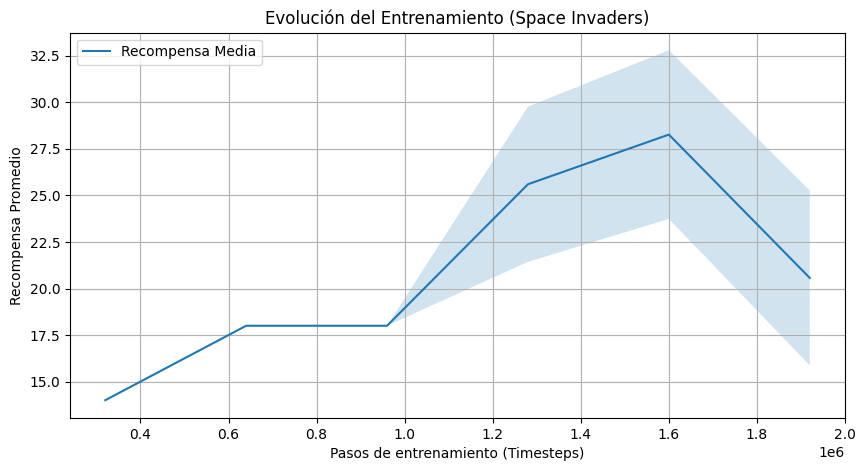

In [8]:
# --- 7. PLOTEAR EVOLUCIÓN DEL ENTRENAMIENTO ---
def plot_training_evolution(log_path):
    data = np.load(os.path.join(log_path, "evaluations.npz"))
    timesteps = data['timesteps']
    results = data['results']
    
    # Calculamos la media y la desviación estándar de las evaluaciones
    mean_rewards = np.mean(results, axis=1)
    std_rewards = np.std(results, axis=1)

    plt.figure(figsize=(10, 5))
    plt.plot(timesteps, mean_rewards, label="Recompensa Media")
    plt.fill_between(timesteps, mean_rewards - std_rewards, 
                     mean_rewards + std_rewards, alpha=0.2)
    
    plt.title("Evolución del Entrenamiento (Space Invaders)")
    plt.xlabel("Pasos de entrenamiento (Timesteps)")
    plt.ylabel("Recompensa Promedio")
    plt.grid(True)
    plt.legend()
    plt.savefig(os.path.join(log_path, "training_curve.png"))
    plt.show()

plot_training_evolution(LOGS_DIR)

In [9]:
# --- 8. TESTEAR EL MEJOR MODELO ---

def test_best_model(model_path, env_id, n_episodes=100):
    # Crear entorno de test idéntico al de entrenamiento
    test_env = DummyVecEnv([make_clipped_env(env_id, seed=0)])
    test_env = VecFrameStack(test_env, n_stack=4)
    
    model = A2C.load(model_path)
    
    print(f"Evaluando modelo en {n_episodes} episodios...")
    mean_reward, std_reward = evaluate_policy(
        model, 
        test_env, 
        n_eval_episodes=n_episodes, 
        deterministic=True
    )
    
    print("-" * 30)
    print(f"Métricas finales tras {n_episodes} episodios:")
    print(f"Puntaje promedio: {mean_reward:.2f} pts")
    print(f"Desviación estándar: {std_reward:.2f} pts")
    print("-" * 30)
    
    return mean_reward

mean_score = test_best_model(best_model_path, ENV_NAME, n_episodes=100)

Evaluando modelo en 100 episodios...
------------------------------
Métricas finales tras 100 episodios:
Puntaje promedio: 28.23 pts
Desviación estándar: 4.54 pts
------------------------------


### Conclusiones

#### Comparación de Arquitecturas:


##### Estructuras Comparativas de los 4 Modelos

| Componente | Modelo 1 (D3QN) | Modelo 2 (DQN) | Modelo 3 (PPO) | Modelo 4 (A2C) |
|------------|-----------------|----------------|----------------|----------------|
| **Framework** | Keras/TensorFlow | PyTorch/SB3 | PyTorch/SB3 | PyTorch/SB3 |
| **GPU** | NVIDIA (CUDA) | AMD (ROCm) | AMD (ROCm) | AMD (ROCm) |
| **Conv 1** | 32 filtros, 8×8, stride=4 | 32 filtros, 8×8, stride=4 | 32 filtros, 8×8, stride=4 | 32 filtros, 8×8, stride=4 |
| **Conv 2** | 64 filtros, 4×4, stride=2 | 64 filtros, 4×4, stride=2 | 64 filtros, 4×4, stride=2 | 64 filtros, 4×4, stride=2 |
| **Conv 3** | 64 filtros, 3×3, stride=1 | 64 filtros, 3×3, stride=1 | 64 filtros, 3×3, stride=1 | 64 filtros, 3×3, stride=1 |
| **Flatten** | 3136 valores | 3136 valores | 3136 valores | 3136 valores |
| **Capa Intermedia** | 512 neuronas | 512 neuronas | 512 neuronas | 512 neuronas |
| **Arquitectura Final** | **DUELING:** <br>• Value Stream: V(s)<br>• Advantage Stream: A(s,a)<br>• Q(s,a) = V(s) + A(s,a) | **STANDARD:** <br>• Directa: 512 → 6 Q-values<br>• Sin ramas adicionales | **ACTOR-CRITIC:**<br>• Actor Head: π(a\|s)<br>• Critic Head: V(s)<br>• Dos salidas separadas | **ACTOR-CRITIC:**<br>• Actor Head: π(a\|s)<br>• Critic Head: V(s)<br>• Dos salidas separadas |
| **Parámetros Totales** | ~1.6M | ~1.5M | ~1.5M | ~1.5M |
| **Entornos Paralelos** | 1 | 4 | 4 | 16 |
| **Tipo de Algoritmo** | Value-Based (Q-Learning) | Value-Based (Q-Learning) | Policy-Based (On-Policy) | Policy-Based (On-Policy) |



##### **1. Framework y Compatibilidad GPU**
- **Modelo 1 (D3QN)**: TensorFlow backend → **NVIDIA GPU (CUDA)** - Dueling Double Deep Q-network
- **Modelo 2 (DQN)**: PyTorch backend → **AMD GPU (ROCm)** - Deep Q-Network estándar
- **Modelo 3 (PPO)**: PyTorch backend → **AMD GPU (ROCm)** - Proximal Policy Optimization 
- **Modelo 4 (A2C)**: PyTorch backend → **AMD GPU (ROCm)** - Advantage Actor-Critic

##### **2. Arquitecturas de Aprendizaje por Refuerzo**

**Modelo 1 (D3QN) - Keras/Keras-RL:**
```
Red Base Simple → Keras-RL agrega Dueling/Double DQN externamente
- enable_dueling_network=True (separa ventaja de valores de estado)
- enable_double_dqn=True (reduce sobreestimación de Q-values)
- La red solo calcula Q-values básicos, las mejoras son externas
```

**Modelo 2 (DQN) - PyTorch/SB3:**
```
Arquitectura Standard con 2 Subredes:
├─ q_net (red principal - se entrena constantemente)
└─ q_net_target (copia estable - actualización periódica)

Cada una contiene:
├─ NatureCNN (extractor de características convolucionales)
└─ QNetwork (cabeza de decisión con 6 salidas Q-values)
```

**Modelo 3 (PPO) - PyTorch/SB3:**
```
Arquitectura Actor-Critic con Policy Gradient:
├─ policy_net (actor - decide acciones)
├─ value_net (crítico - estima valores de estado)
└─ Ambas comparten NatureCNN como extractor de características

Policy Head: 6 salidas (probabilidades de acciones)
Value Head: 1 salida (estimación del valor del estado)
```

**Modelo 4 (A2C) - PyTorch/SB3:**
```
Arquitectura Actor-Critic Sincrónica:
├─ policy_net (actor - política estocástica)
├─ value_net (crítico - función de valor)
└─ Entrenamiento sincronizado en 16 entornos paralelos

Actor: Produce distribución de probabilidad sobre acciones
Crítico: Estima el valor esperado del estado actual
```

##### **3. Preprocesamiento y Configuración de Entornos por Modelo**

**Modelo 1 (D3QN) - Keras/TensorFlow:**
- **Formato de entrada:** Necesita `Permute((2, 3, 1))` para reorganizar dimensiones
- **Transformación:** `(4, 84, 84)` → `(84, 84, 4)` (channels-last)
- **Procesamiento manual:** Clase `AtariProcessor` personalizada
  - `process_observation()`: Redimensiona con Pillow a 84×84 escala de grises
  - `process_state_batch()`: Normalización 0-255 → 0-1
  - `process_reward()`: Clipping manual entre -1 y 1
- **Entornos:** 1 entorno secuencial (sin paralelización)

**Modelo 2 (DQN) - PyTorch/SB3:**
- **Formato de entrada:** `(4, 84, 84)` channels-first nativo
- **Wrappers automáticos:** `AtariWrapper` + `VecFrameStack`
- **Normalización:** Automática dentro de `CnnPolicy` (0-255 → 0-1)
- **Reward clipping:** `TransformReward(lambda r: np.sign(r))`
- **Entornos:** 4 entornos paralelos con seeds diferentes
- **Monitoring:** Muestra recompensa clipeada (no score original)

**Modelo 3 (PPO) - PyTorch/SB3:**
- **Formato idéntico a Modelo 2:** channels-first, normalización automática
- **Configuración específica:**
  - `n_steps=2048`: Recolecta más experiencias antes de actualizar
  - `batch_size=256`: Lotes más grandes para estabilidad
  - `n_epochs=10`: Múltiples pasadas sobre los mismos datos
- **Entornos:** 4 paralelos (optimizado para policy gradients)
- **GAE:** `gae_lambda=0.95` para estimación de ventaja

**Modelo 4 (A2C) - PyTorch/SB3:**
- **Formato base igual:** channels-first, wrappers automáticos
- **Configuración única:**
  - `n_steps=5`: Actualización muy frecuente (cada 5 pasos)
  - **16 entornos paralelos:** Máxima paralelización
  - `use_rms_prop=True`: Optimizador RMSprop específico
- **Sincronización:** Todos los entornos se actualizan simultáneamente
- **Speed vs Stability:** Prioriza velocidad sobre estabilidad

##### **4. Diferencias Clave en el Pipeline de Datos**

| Aspecto | D3QN (Modelo 1) | DQN (Modelo 2) | PPO (Modelo 3) | A2C (Modelo 4) |
|---------|-----------------|----------------|----------------|----------------|
| **Paralelización** | No (1 env) | Moderada (4 envs) | Moderada (4 envs) | Alta (16 envs) |
| **Frecuencia Update** | Cada 4 pasos | Cada 4 pasos | Cada 2048 pasos | Cada 5 pasos |
| **Buffer/Memory** | 500K transiciones | 300K transiciones | No buffer | No buffer |
| **Batch Processing** | 32 samples | 32 samples | 256 samples | 80 samples (16×5) |
| **Reward Display** | Clipeada (-1,0,1) | Clipeada (-1,0,1) | Clipeada (-1,0,1) | Clipeada (-1,0,1) |

---

#### **Rendimiento Esperado y Características por Modelo**

##### **Modelo 1 (D3QN) - Keras/TensorFlow**
**Rendimiento esperado:** Alto rendimiento final, pero con curva de aprendizaje inestable
-  **Ventajas:**
  - Dueling + Double DQN reduce sobreestimación y acelera convergencia
  - Replay Buffer de 500K permite re-aprender de experiencias valiosas
  - Arquitectura probada en papers originales de DeepMind
  - Optimizado para NVIDIA GPU con CUDA

-  **Desventajas:**
  - Muy sensible a hiperparámetros (epsilon decay, learning rate)
  - Propenso a *catastrophic forgetting* en fases avanzadas
  - Alto consumo de RAM (500K buffer de imágenes 84×84×4)
  - Entrenamiento secuencial (sin paralelización)

##### **Modelo 2 (DQN) - PyTorch/SB3**
**Rendimiento esperado:** Consistente pero más lento que D3QN
-  **Ventajas:**
  - Implementación estable y mantenida activamente
  - Compatible con AMD GPU (ROCm) 
  - TensorBoard integrado para monitoreo
  - 4 entornos paralelos aceleran recolección de datos

-  **Desventajas:**
  - Sin mejoras Dueling/Double (DQN básico)
  - Buffer más pequeño (300K vs 500K)
  - Puede sufrir sobreestimación de Q-values
  - Convergencia más lenta que variantes avanzadas

##### **Modelo 3 (PPO) - PyTorch/SB3** 
**Rendimiento esperado:** Más estable, convergencia gradual pero robusta
-  **Ventajas:**
  - **Muy estable** - difícil que colapse durante entrenamiento
  - Policy gradient permite exploración natural
  - GAE reduce varianza en estimación de ventaja
  - Estándar de la industria (OpenAI, DeepMind)
  - Fácil de tunear hiperparámetros

-  **Desventajas:**
  - Más lento por episodio (n_steps=2048)
  - Requiere más timesteps para converger
  - Sin replay buffer (menos eficiente en datos)
  - Puede converger a políticas subóptimas localmente

##### **Modelo 4 (A2C) - PyTorch/SB3**
**Rendimiento esperado:** Aprendizaje muy rápido, pero potencialmente inestable
-  **Ventajas:**
  - **Entrenamiento más rápido** (16 entornos paralelos)
  - Muy bajo uso de memoria (sin replay buffer)
  - Actualizaciones frecuentes (cada 5 pasos)
  - Ideal para prototipado rápido y experimentación

-  **Desventajas:**
  - **Muy sensible** al learning rate y otros hiperparámetros
  - Puede colapsar repentinamente ("policy collapse")
  - Gradientes ruidosos por alta frecuencia de updates
  - Requiere fine-tuning cuidadoso

#### **Recomendaciones de Uso**

| **Situación** | **Modelo Recomendado** | **Razón** |
|---------------|------------------------|-----------|
| **Máximo rendimiento** | Modelo 1 (D3QN) | Dueling + Double DQN + gran replay buffer |
| **Compatibilidad AMD** | Modelo 2 (DQN) | PyTorch + SB3 con soporte ROCm |
| **Estabilidad/Producción** | Modelo 3 (PPO) | Muy difícil que falle, industria estándar |
| **Experimentación rápida** | Modelo 4 (A2C) | Entrena más rápido, resultados tempranos |
| **Hardware limitado** | Modelo 4 (A2C) | Menor uso de memoria, sin buffer |
| **Principiantes** | Modelo 3 (PPO) | Más tolerante a errores de configuración |

---

#### **Guía de Selección de Hardware y Framework**

| **Hardware** | **Modelo Recomendado** | **Framework** | **Justificación** |
|--------------|------------------------|---------------|-------------------|
| **GPU NVIDIA** | Modelo 1 (D3QN) | TensorFlow + Keras-RL | CUDA optimizado, Dueling/Double DQN nativo |
| **GPU AMD** | Modelos 2-4 | PyTorch + SB3 | Soporte ROCm, biblioteca moderna y mantenida |
| **Solo CPU** | Modelo 4 (A2C) | PyTorch + SB3 | Paralelización eficiente, bajo uso de memoria |

#### **Lecciones Aprendidas del Entrenamiento**

##### **1. Configuración del Entorno (Crítico para el Éxito)**
La configuración correcta del entorno Atari resultó fundamental para el rendimiento:
- **Reward Clipping:** Usar recompensas clipeadas (-1, 0, 1) en lugar del score original mejoró significativamente la consistencia del aprendizaje
- **Impacto:** Los agentes eliminaron más enemigos por episodio y mostraron comportamiento más estable
- **Razón:** Evita que recompensas extremas dominen el gradiente y permite convergencia más uniforme

##### **2. Frame Stacking (Obligatorio para la Percepción de Movimiento)**
El apilamiento de 4 frames consecutivos demostró ser esencial:
- **Configuración óptima:** 4 frames (valor estándar en literatura)
- **Problema con <4 frames:** El agente no percibe direcciones de movimiento, comportamiento errático
- **Problema con >4 frames:** Mayor costo computacional sin mejoras significativas
- **Resultado:** Permite al agente inferir velocidades y trayectorias de proyectiles/enemigos

##### **3. Paralelización de Entornos (Aceleración Dramática)**
El entrenamiento con múltiples entornos simultáneos mostró beneficios substanciales:
- **Implementación:** Seeds diferentes (+1, +2, +3...) para evitar sincronización
- **Impacto:** Mejora notable en el mean reward y velocidad de convergencia
- **Modelo 2-3:** 4 entornos paralelos → Recolección de datos 4x más rápida
- **Modelo 4:** 16 entornos paralelos → Máxima eficiencia, pero requiere más timesteps para convergencia final

##### **4. Optimización de Hiperparámetros (Proceso Iterativo Crítico)**
El ajuste fino de hiperparámetros requirió múltiples iteraciones experimentales:
- **Exploración (ε-greedy):** Encontrar el balance entre exploración inicial y explotación final
- **Learning Rate:** Valores muy altos causan inestabilidad, muy bajos convergen lentamente
- **Target Update Frequency:** Frecuencia de actualización de red objetivo afecta estabilidad
- **Observación:** Cada algoritmo tiene sensibilidades diferentes a estos parámetros

##### **5. Características de Entrenamiento por Algoritmo**

**A2C (Modelo 4):** Entrenamiento más rápido pero requiere más timesteps
- **Ventaja:** 16 entornos paralelos proporcionan experiencia masiva por segundo
- **Desafío:** La alta paralelización introduce ruido que requiere más datos para convergencia estable
- **Recomendación:** Ideal para experimentos rápidos, requiere paciencia para resultados óptimos

#### **Comparativa Técnica Final de Algoritmos**

| **Característica** | **DQN** | **A2C** | **PPO** |
|---|---|---|---|
| **Tipo de Algoritmo** | Value-based | Actor-Critic | Actor-Critic (Policy Grad) |
| **Uso de Memoria (RAM)** | Muy Alto (Buffer) | Muy Bajo | Moderado |
| **Estabilidad** | Baja | Media | Muy Alta |
| **Paralelismo** | Bajo | Muy Alto | Alto |
| **Facilidad de uso** | Difícil de tunear | Sensible | Fácil |
| **Velocidad inicial** | Lenta | Muy Rápida | Moderada |
| **Convergencia final** | Variable | Requiere paciencia | Consistente |
| **Uso recomendado** | Máximo rendimiento | Experimentación | Producción |

---

#### **Análisis Detallado de los Algoritmos Implementados**

##### **1. DQN (Deep Q-Network)**


**En qué es mejor:** Eficiencia de datos. Gracias al Replay Buffer, DQN "relee" sus experiencias pasadas muchas veces. Es excelente si el simulador es lento, porque aprovecha cada frame al máximo.

**Punto débil:** Es muy inestable y lento de entrenar en tiempo real. Necesita mucha memoria RAM para guardar el buffer de imágenes y es propenso a sobreestimar el valor de ciertas acciones.

**Sentido:** Si se tiene mucha RAM y se quiere un agente que eventualmente alcance un nivel de juego casi perfecto, aunque tarde horas.

##### **2. A2C (Advantage Actor-Critic)**


**En qué es mejor:** Velocidad y simplicidad. No necesita un Replay Buffer, por lo que consume muy poca RAM. Al usar muchos entornos en paralelo (por ejemplo, 16 "ventanas" de Space Invaders a la vez), el entrenamiento se siente muy fluido.

**Punto débil:** Es muy sensible a los hiperparámetros (especialmente al learning_rate). Si la tasa de aprendizaje es muy alta, el modelo "colapsa" y deja de aprender de repente.

**Sentido:** Se se tiene un procesador con muchos núcleos y se quieren ver resultados rápidos sin consumir toda la memoria de tu ordenador.

##### **3. PPO (Proximal Policy Optimization)** (Mas usado actualmente)

**En qué es mejor:** Robustez y estabilidad. PPO está diseñado para que la actualización de la red neuronal no sea "demasiado grande", lo que evita que el agente "desaprenda" lo que ya sabía (algo que le pasa mucho a A2C).

**Punto débil:** Es un poco más complejo de configurar y puede ser más lento por paso que A2C, ya que realiza múltiples épocas de optimización sobre el mismo lote de datos.

**Sentido:** Es la opción recomendada para casi cualquier proyecto moderno. Es el más equilibrado.


